# Screen parabola vs. eye

Top-down cross-section of the parabolic-cylinder screen: `y = A - B*x²`, with the mouse eye at the
origin (`x` = lateral, `y` = forward/depth). Marks the eye, overlays a circle centered on the eye
with radius = *distance to eye*, and shoots rays from the eye at ±0/30/60/90° azimuth to show where
each ray meets the parabola vs. the circle. Rays landing *inside* the circle = screen closer than
`distance_to_eye`; *outside* = farther.

**Edit the values below and re-run** — everything is plain variables, nothing is loaded from a
config file. (Current rig values: `A=13`, `B=0.055`, in `display_calibration/rig_geometry.yaml`.)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ── play with these ───────────────────────────────────────────────
A = 13.0                    # cm   — parabola_A: eye→vertex (closest screen point) depth
B = 0.055                   # 1/cm — parabola_B: curvature (higher = more curved)
distance_to_eye = A         # cm   — circle radius; set your own measured value if it differs from A
ray_angles = [0, 30, 60, 90]  # deg — azimuths to shoot (mirrored to ±); 0° = straight ahead (+y)
# ──────────────────────────────────────────────────────────────────

In [7]:
def parabola(x, A, B):
    """Screen cross-section: y = A - B*x²  (eye at origin, y = forward)."""
    return A - B * x**2

def circle(r, n=400):
    """x, y of a circle of radius r centered on the eye (origin)."""
    t = np.linspace(0, 2*np.pi, n)
    return r*np.cos(t), r*np.sin(t)

def screen_edge_x(A, B):
    """x where the parabola meets the eye's coronal plane (y=0) = the ±90° azimuth edge."""
    return np.sqrt(A / B)

def ray_dir(az_deg):
    """Unit direction of a ray from the eye. 0° = forward (+y), +90° = right (+x)."""
    a = np.radians(az_deg)
    return np.sin(a), np.cos(a)

def ray_parabola_t(az_deg, A, B):
    """Distance t along the ray from the eye to the parabola y = A - B*x².

    Sub dy*t = A - B*(dx*t)²  →  (B dx²) t² + dy t - A = 0, take the positive root.
    """
    dx, dy = ray_dir(az_deg)
    a = B * dx**2
    if np.isclose(a, 0.0):          # az = 0 → straight to the vertex
        return A / dy
    return (-dy + np.sqrt(dy**2 + 4*a*A)) / (2*a)

  az°  t_parabola  t_circle   Δ (par-cir)   side
  -90       15.37     13.00         +2.37   outside
  -60       12.70     13.00         -0.30   inside
  -30       12.52     13.00         -0.48   inside
    0       13.00     13.00         +0.00   on
   30       12.52     13.00         -0.48   inside
   60       12.70     13.00         -0.30   inside
   90       15.37     13.00         +2.37   outside


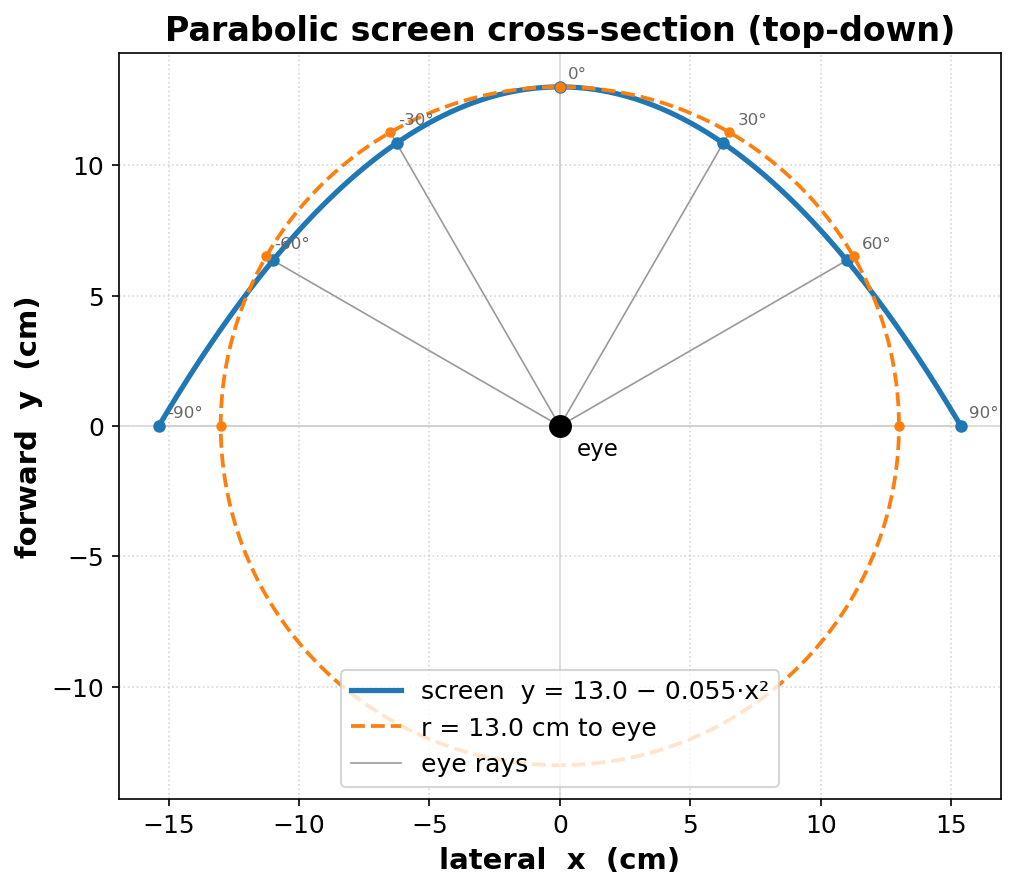


screen edge (±90° az) at x = ±15.37 cm, y = 0


In [8]:
x_edge = screen_edge_x(A, B)
x = np.linspace(-x_edge, x_edge, 400)
y = parabola(x, A, B)
cx, cy = circle(distance_to_eye)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, y, color="tab:blue", lw=2.5, label=f"screen  y = {A} − {B}·x²")
ax.plot(cx, cy, color="tab:orange", ls="--", lw=1.8, label=f"r = {distance_to_eye} cm to eye")

# rays from the eye, with parabola (blue) & circle (orange) intersections
signed = sorted({0, *ray_angles, *(-a for a in ray_angles)})
print(f"{'az°':>5} {'t_parabola':>11} {'t_circle':>9}  {'Δ (par-cir)':>12}   side")
for i, az in enumerate(signed):
    dx, dy = ray_dir(az)
    t_p = ray_parabola_t(az, A, B)       # distance to parabola
    t_c = distance_to_eye                 # distance to circle
    t_draw = max(t_p, t_c)
    ax.plot([0, dx*t_draw], [0, dy*t_draw], color="0.6", lw=0.8, zorder=1,
            label="eye rays" if i == 0 else None)
    ax.plot(dx*t_p, dy*t_p, "o", ms=5, color="tab:blue", zorder=6)   # parabola hit
    ax.plot(dx*t_c, dy*t_c, "o", ms=4, color="tab:orange", zorder=6) # circle hit
    ax.annotate(f"{az}°", (dx*t_draw, dy*t_draw), textcoords="offset points",
                xytext=(4, 4), fontsize=8, color="0.4")
    side = "inside" if t_p < t_c else ("outside" if t_p > t_c else "on")
    print(f"{az:>5} {t_p:>11.2f} {t_c:>9.2f}  {t_p - t_c:>+12.2f}   {side}")

# eye at the origin
ax.plot(0, 0, marker="o", ms=10, color="k", zorder=7)
ax.annotate("eye", (0, 0), textcoords="offset points", xytext=(8, -14), fontsize=11)

ax.axhline(0, color="0.85", lw=0.8)
ax.axvline(0, color="0.85", lw=0.8)
ax.set_aspect("equal")
ax.set_xlabel("lateral  x  (cm)")
ax.set_ylabel("forward  y  (cm)")
ax.set_title("Parabolic screen cross-section (top-down)")
ax.legend(loc="lower center")
ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"\nscreen edge (±90° az) at x = ±{x_edge:.2f} cm, y = 0")